# fastcausal Demo

Code to demonstrate basic fastcausal capabilities in a Jupyter notebook.

In [1]:
from fastcausal import FastCausal

fc = FastCausal()

### Reading in data

For this demo we use a sample EMA dataset bundled with fastcausal.

To read in your own CSV data file `"mydata.csv"` you would use pandas:

```python
import pandas as pd
df = pd.read_csv("mydata.csv")
```

In [2]:
# Load the sample EMA dataset
df = fc.load_sample("boston")
df

,alcohol_bev,TIB,TST,PANAS_PA,PANAS_NA,worry_scale,PHQ9
0,1.0,9.00,7.333333,44.0,13.0,8.0,0.0
1,0.0,10.25,8.750000,40.0,12.0,14.0,0.0
2,1.0,8.50,7.166667,39.0,12.0,15.0,0.0
3,1.0,8.75,8.083333,39.0,12.0,12.0,0.0
4,1.0,8.25,6.666667,38.0,13.0,15.0,0.0
...,...,...,...,...,...,...,...
636,4.0,8.75,7.916667,29.0,12.0,17.0,3.0
637,4.0,8.50,7.666667,31.0,12.0,17.0,4.0
638,3.0,8.50,7.583333,33.0,13.0,17.0,3.0
639,3.0,9.00,8.166667,31.0,12.0,19.0,2.0


In [3]:
# Add lagged columns (yesterday's values) with a '_lag' suffix
lag_stub = "_lag"
df_lag = fc.add_lag_columns(df, lag_stub=lag_stub)
df_lag

,alcohol_bev,TIB,TST,PANAS_PA,PANAS_NA,worry_scale,PHQ9,alcohol_bev_lag,TIB_lag,TST_lag,PANAS_PA_lag,PANAS_NA_lag,worry_scale_lag,PHQ9_lag
0,0.0,10.25,8.750000,40.0,12.0,14.0,0.0,1.0,9.00,7.333333,44.0,13.0,8.0,0.0
1,1.0,8.50,7.166667,39.0,12.0,15.0,0.0,0.0,10.25,8.750000,40.0,12.0,14.0,0.0
2,1.0,8.75,8.083333,39.0,12.0,12.0,0.0,1.0,8.50,7.166667,39.0,12.0,15.0,0.0
3,1.0,8.25,6.666667,38.0,13.0,15.0,0.0,1.0,8.75,8.083333,39.0,12.0,12.0,0.0
4,0.0,8.25,7.416667,37.0,12.0,16.0,0.0,1.0,8.25,6.666667,38.0,13.0,15.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
635,4.0,8.75,7.916667,29.0,12.0,17.0,3.0,6.0,7.00,6.166667,31.0,15.0,18.0,3.0
636,4.0,8.50,7.666667,31.0,12.0,17.0,4.0,4.0,8.75,7.916667,29.0,12.0,17.0,3.0
637,3.0,8.50,7.583333,33.0,13.0,17.0,3.0,4.0,8.50,7.666667,31.0,12.0,17.0,4.0
638,3.0,9.00,8.166667,31.0,12.0,19.0,2.0,3.0,8.50,7.583333,33.0,13.0,17.0,3.0


In [4]:
# Standardize all columns to zero mean and unit variance
df_std = fc.standardize(df_lag)
df_std

,alcohol_bev,TIB,TST,PANAS_PA,PANAS_NA,worry_scale,PHQ9,alcohol_bev_lag,TIB_lag,TST_lag,PANAS_PA_lag,PANAS_NA_lag,worry_scale_lag,PHQ9_lag
0,-0.719523,0.944857,0.714248,1.402556,-0.441798,-1.024608,-0.960780,-0.044992,0.019741,-0.338674,1.807201,-0.237646,-1.967668,-0.959849
1,-0.048003,-0.349098,-0.462667,1.299793,-0.441798,-0.866138,-0.960780,-0.718556,0.944201,0.714324,1.397129,-0.441798,-1.019513,-0.959849
2,-0.048003,-0.164248,0.218705,1.299793,-0.441798,-1.341548,-0.960780,-0.044992,-0.350043,-0.462557,1.294611,-0.441798,-0.861488,-0.959849
3,-0.048003,-0.533949,-0.834325,1.197030,-0.237646,-0.866138,-0.960780,-0.044992,-0.165151,0.218795,1.294611,-0.441798,-1.335565,-0.959849
4,-0.719523,-0.533949,-0.276838,1.094266,-0.441798,-0.707668,-0.960780,-0.044992,-0.534935,-0.834203,1.192093,-0.237646,-0.861488,-0.959849
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
635,1.966557,-0.164248,0.094819,0.272162,-0.441798,-0.549198,0.053905,3.322826,-1.459395,-1.205849,0.474466,0.170659,-0.387410,0.054411
636,1.966557,-0.349098,-0.091010,0.477688,-0.441798,-0.549198,0.392133,1.975699,-0.165151,0.094913,0.269430,-0.441798,-0.545436,0.054411
637,1.295037,-0.349098,-0.152953,0.683214,-0.237646,-0.549198,0.053905,1.975699,-0.350043,-0.090910,0.474466,-0.441798,-0.545436,0.392498
638,1.295037,0.020603,0.280648,0.477688,-0.441798,-0.232258,-0.284323,1.302135,-0.350043,-0.152851,0.679503,-0.237646,-0.545436,0.054411


In [5]:
# Get the original column names
cols = df.columns
cols

Index(['alcohol_bev', 'TIB', 'TST', 'PANAS_PA', 'PANAS_NA', 'worry_scale',
       'PHQ9'],
      dtype='str')

In [6]:
# Create temporal prior knowledge explicitly.
# Tier 0 = lag variables (can only be parents)
# Tier 1 = current-day variables
# Lag variables can cause current-day variables, but not vice versa.

knowledge = {
    "addtemporal": {
        0: [col + lag_stub for col in cols],
        1: [col for col in cols],
    }
}
knowledge

{'addtemporal': {0: ['alcohol_bev_lag',
   'TIB_lag',
   'TST_lag',
   'PANAS_PA_lag',
   'PANAS_NA_lag',
   'worry_scale_lag',
   'PHQ9_lag'],
  1: ['alcohol_bev',
   'TIB',
   'TST',
   'PANAS_PA',
   'PANAS_NA',
   'worry_scale',
   'PHQ9']}}

In [7]:
# Run GFCI causal discovery search
result, graph = fc.run_search(
    df_std,
    algorithm="gfci",
    alpha=0.01,
    penalty_discount=1.0,
    knowledge=knowledge,
)

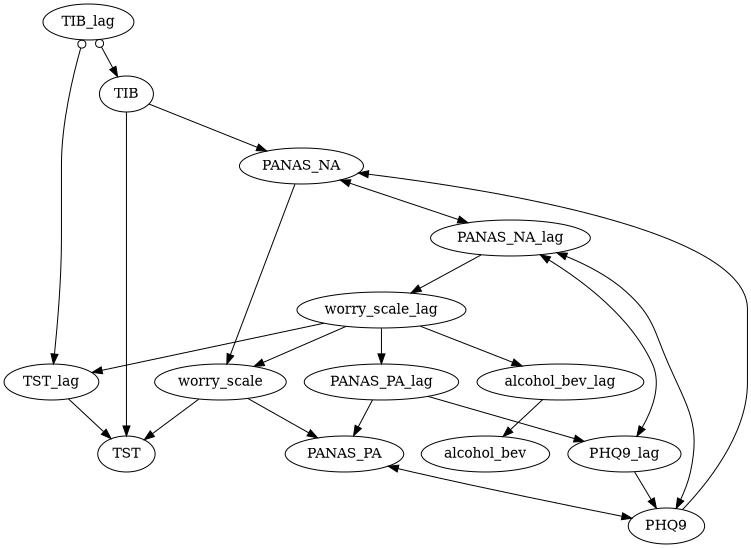

In [8]:
fc.show_graph(graph)

In [9]:
print(f"Edges: {result['num_edges']}")
for e in result["edges"]:
    print(f"  {e}")

Edges: 22
  PANAS_NA <-> PANAS_NA_lag
  PANAS_NA --> worry_scale
  PANAS_NA_lag <-> PHQ9_lag
  PANAS_NA_lag --> worry_scale_lag
  PANAS_PA <-> PHQ9
  PANAS_PA_lag --> PANAS_PA
  PANAS_PA_lag --> PHQ9_lag
  PHQ9 --> PANAS_NA
  PHQ9 <-> PANAS_NA_lag
  PHQ9_lag --> PHQ9
  TIB --> PANAS_NA
  TIB --> TST
  TIB_lag o-> TIB
  TIB_lag o-> TST_lag
  TST_lag --> TST
  alcohol_bev_lag --> alcohol_bev
  worry_scale --> PANAS_PA
  worry_scale --> TST
  worry_scale_lag --> PANAS_PA_lag
  worry_scale_lag --> TST_lag
  worry_scale_lag --> alcohol_bev_lag
  worry_scale_lag --> worry_scale


Show the graph with just the directed edges.

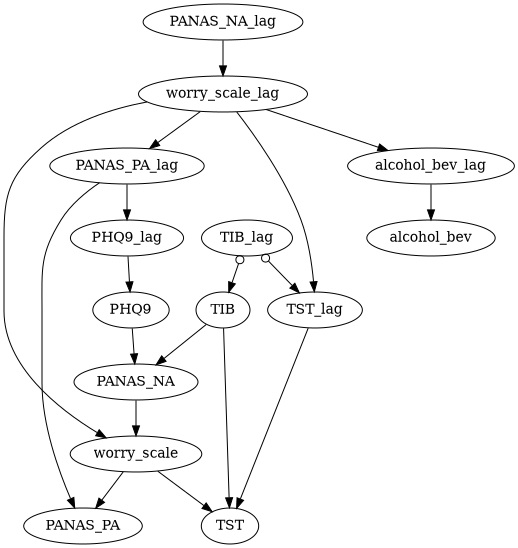

In [10]:
fc.show_graph(graph, directed_only=True)

### Node styling

Let's highlight variable groups: lag variables get a dotted outline,
PANAS_PA is light green, PANAS_NA is light pink, and alcohol_bev
variables are purple rectangles.

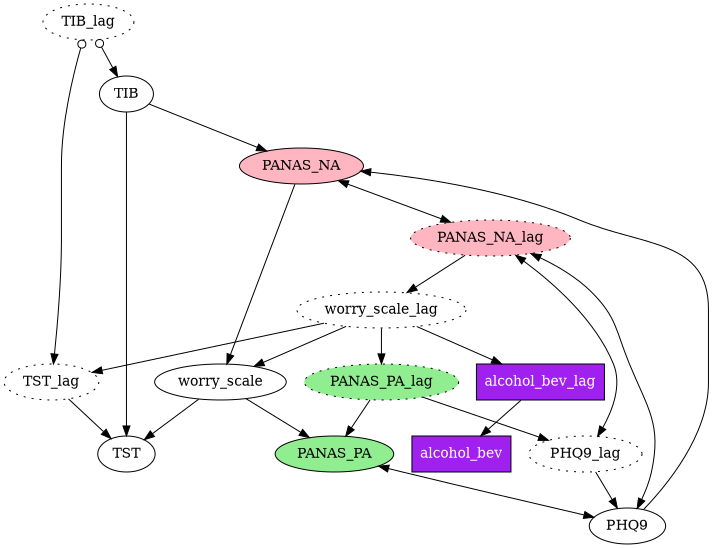

In [11]:
node_styles = [
    {"pattern": "*_lag",        "style": "dotted"},
    {"pattern": "PANAS_PA*",    "style": "filled", "fillcolor": "lightgreen"},
    {"pattern": "PANAS_NA*",    "style": "filled", "fillcolor": "lightpink"},
    {"pattern": "PANAS_PA_lag", "style": "filled,dotted", "fillcolor": "lightgreen"},
    {"pattern": "PANAS_NA_lag", "style": "filled,dotted", "fillcolor": "lightpink"},
    {"pattern": "alcohol_bev*", "shape": "box", "style": "filled",
     "fillcolor": "purple", "fontcolor": "white"},
]

fc.show_graph(graph, node_styles=node_styles)

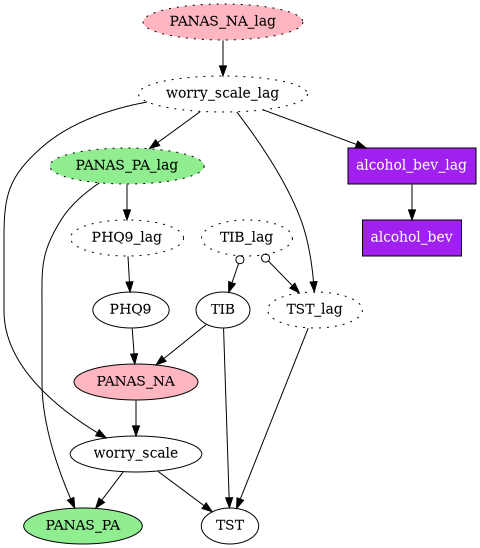

In [12]:
# Styled graph with directed edges only
fc.show_graph(graph, node_styles=node_styles, directed_only=True)

### Multi-graph comparison

Compare results from different penalty discount values side-by-side.
Nodes are pinned at shared positions so differences are easy to spot.
Disconnected nodes are grayed out by default.

In [13]:
# Run two more searches with higher penalty discounts
result2, graph2 = fc.run_search(
    df_std, algorithm="gfci", alpha=0.01,
    penalty_discount=2.0, knowledge=knowledge,
)

result3, graph3 = fc.run_search(
    df_std, algorithm="gfci", alpha=0.01,
    penalty_discount=3.0, knowledge=knowledge,
)


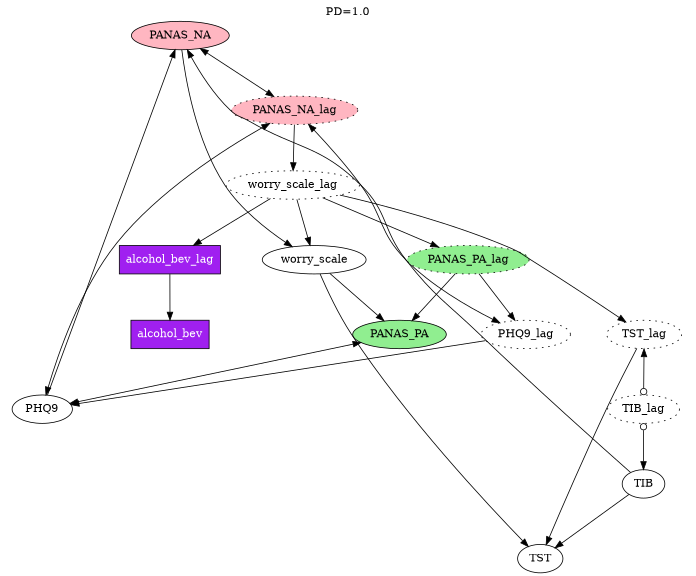
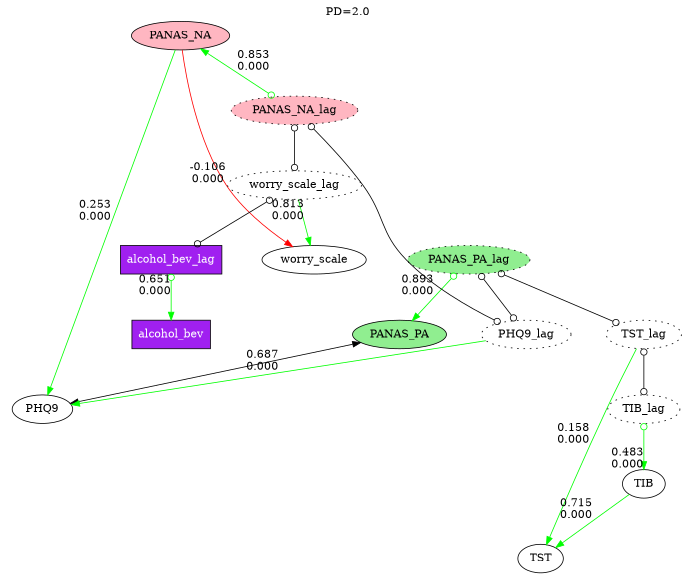
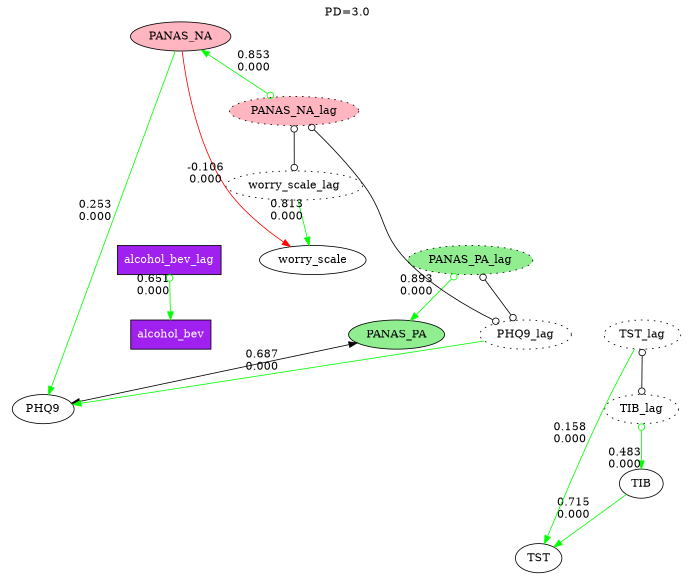

In [14]:
# Compare three graphs side-by-side
fc.show_n_graphs(
    [graph, graph2, graph3],
    node_styles=node_styles,
    gray_disconnected=True,
    labels=["PD=1.0", "PD=2.0", "PD=3.0"],
    graph_size="10,8",
)


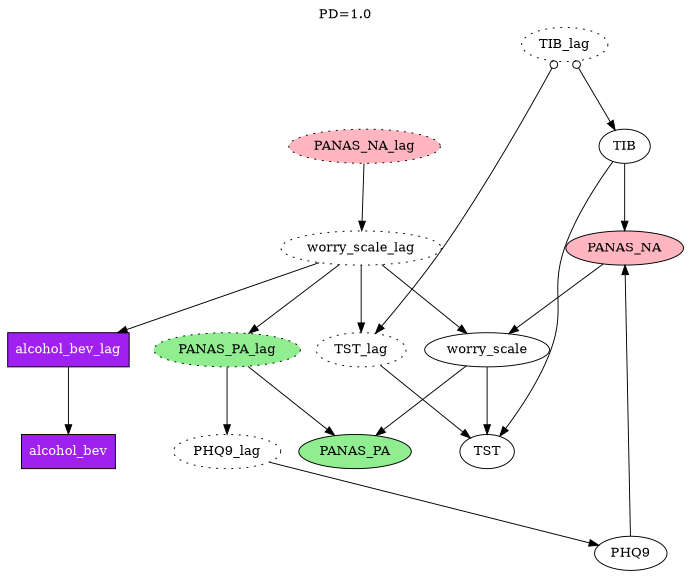
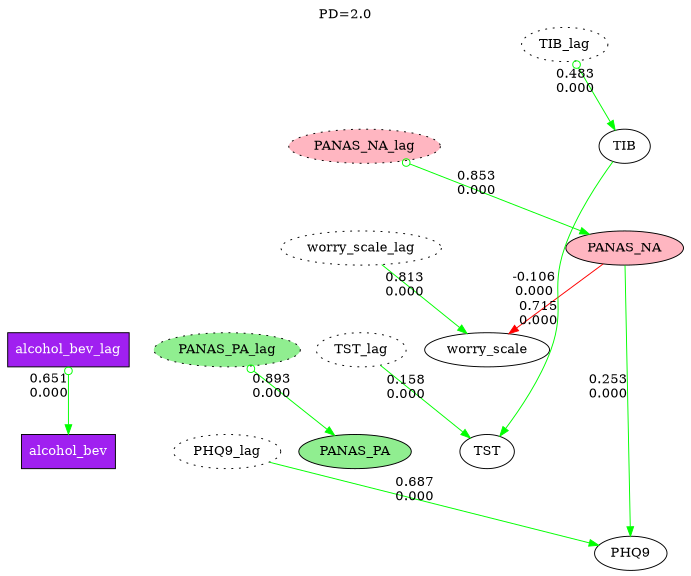
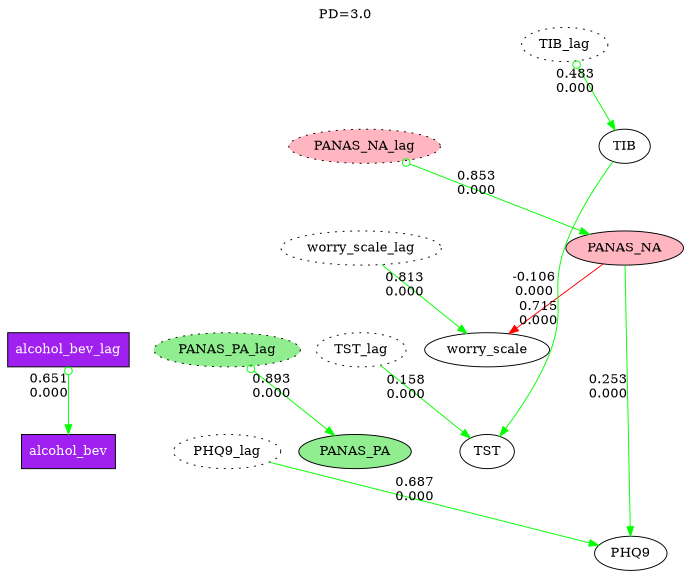

In [15]:
# Directed edges only
fc.show_n_graphs(
    [graph, graph2, graph3],
    node_styles=node_styles,
    gray_disconnected=True,
    directed_only=True,
    labels=["PD=1.0", "PD=2.0", "PD=3.0"],
    graph_size="10,8",
)


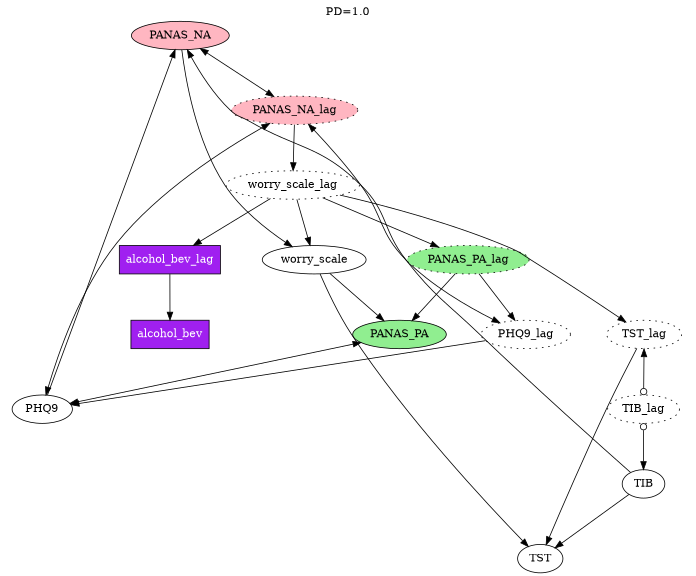
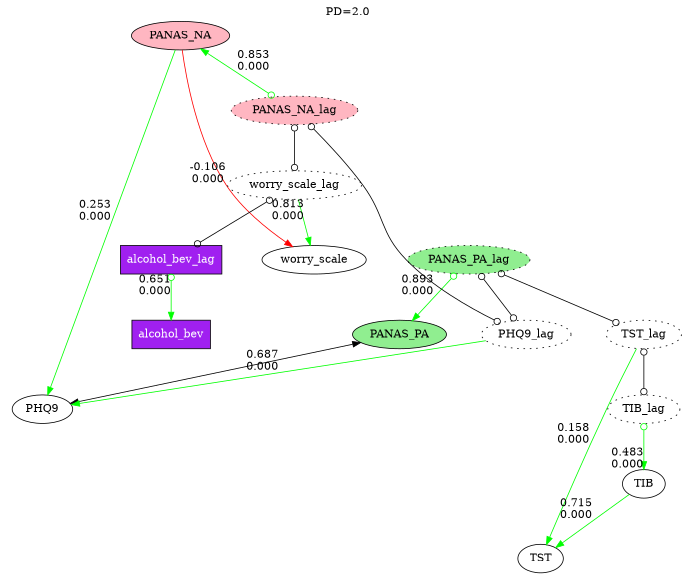
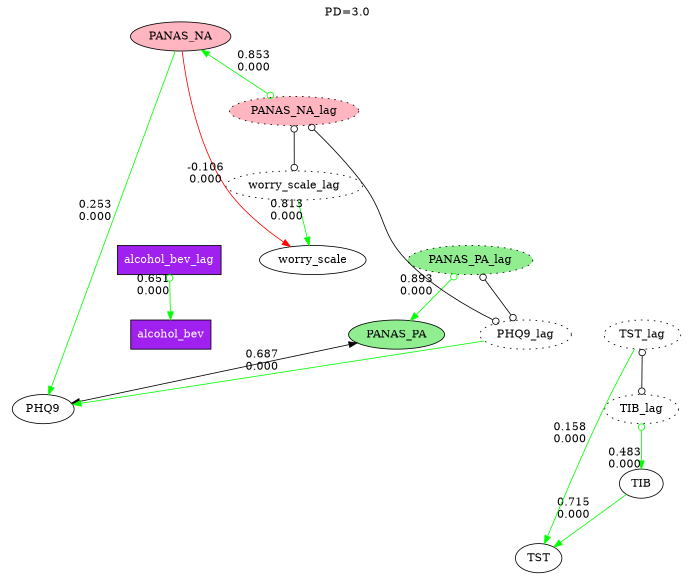

In [16]:
# Without graying out disconnected nodes
fc.show_n_graphs(
    [graph, graph2, graph3],
    node_styles=node_styles,
    gray_disconnected=False,
    labels=["PD=1.0", "PD=2.0", "PD=3.0"],
    graph_size="10,8",
)

In [17]:
# Save graphs to PNG files
fc.save_n_graphs(
    [graph, graph2, graph3],
    ["paired_graph_pd1", "paired_graph_pd2", "paired_graph_pd3"],
    node_styles=node_styles,
    gray_disconnected=True,
    labels=["PD=1.0", "PD=2.0", "PD=3.0"],
    graph_size="10,8",
    res=300,
)
print("Saved: paired_graph_pd1.png, paired_graph_pd2.png, paired_graph_pd3.png")

Saved: paired_graph_pd1.png, paired_graph_pd2.png, paired_graph_pd3.png
